# EDA & Modeling — Breast Cancer Wisconsin Dataset

**Goal**: Classify a breast mass as **malignant** or **benign** based on 30 numerical features computed from a digitized image of a fine needle aspirate (FNA).

Dataset: `sklearn.datasets.load_breast_cancer` — 569 samples, 30 features, all numerical.

---

## Why this dataset looks very different from the Adult / Census Income one

This is intentional — to expose you to a different EDA flavor:

| Aspect | Adult (Census Income) | Breast Cancer Wisconsin |
|---|---|---|
| Feature types | mixed (numerical + categorical) | **all numerical, continuous** |
| Missing values | yes (`?`) | none |
| Sample size | ~49,000 | 569 (small!) |
| Number of features | 14 | 30 (relatively high-dim) |
| Class balance | imbalanced (~76% / 24%) | moderately balanced (~63% / 37%) |
| Domain | demographic/economic | medical imaging |
| EDA focus | encoding, imputation, imbalance | **distributions, correlations, multicollinearity** |

Because all features are continuous and come from the same domain (cell nuclei measurements), the EDA shifts focus toward **distribution shapes, group structure, and inter-feature correlations**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Load the data

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

# Target encoding: 0 = malignant, 1 = benign (sklearn's convention)
print("Shape:", df.shape)
print("Target labels:", dict(enumerate(data.target_names)))
df.head()

Shape: (569, 31)
Target labels: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

## 2. Domain primer — what do these features actually measure?

Each row corresponds to one breast mass. The 30 features are derived from a digitized image of a fine needle aspirate (FNA), measuring properties of the cell nuclei found in the sample.

For each nucleus, **10 base properties** are computed:

| Feature | Meaning |
|---|---|
| `radius` | mean distance from center to perimeter points |
| `texture` | standard deviation of gray-scale values |
| `perimeter` | perimeter of the nucleus |
| `area` | area of the nucleus |
| `smoothness` | local variation in radius lengths |
| `compactness` | perimeter² / area − 1 |
| `concavity` | severity of concave portions of the contour |
| `concave points` | number of concave portions of the contour |
| `symmetry` | symmetry of the nucleus |
| `fractal dimension` | "coastline approximation" of the contour |

Each of these is reported in **three flavors**, giving us 10 × 3 = 30 features:

- `mean ...` — mean across all nuclei in the image
- `... error` — standard error of that measurement
- `worst ...` — mean of the three largest values

**Why this matters for EDA**: Some features are by construction tightly related (`radius`, `perimeter`, `area` all measure size). We should expect **strong multicollinearity** — and we'll see it in the correlation heatmap.

In [4]:
target = "target"
num_cols = [c for c in df.columns if c != target]

mean_cols  = [c for c in num_cols if c.startswith("mean")]
error_cols = [c for c in num_cols if "error" in c]
worst_cols = [c for c in num_cols if c.startswith("worst")]

print(f"mean  features: {len(mean_cols)}")
print(f"error features: {len(error_cols)}")
print(f"worst features: {len(worst_cols)}")
print(f"total:          {len(num_cols)}")

mean  features: 10
error features: 10
worst features: 10
total:          30


## 3. Missing values & duplicates

This dataset is clean — but we always check.

In [5]:
print("Total missing values:", df.isna().sum().sum())
print("Duplicate rows:      ", df.duplicated().sum())

Total missing values: 0
Duplicate rows:       0


## 4. Target distribution

Important: if classes are heavily skewed, accuracy alone can be misleading.

target
0    212
1    357
Name: count, dtype: int64

Malignant share: 37.3%
Benign share:    62.7%


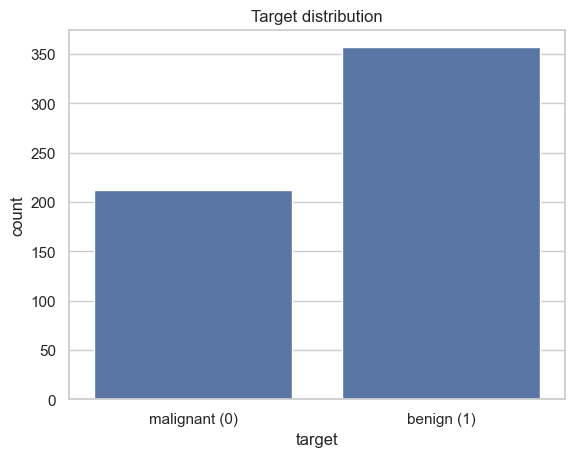

In [6]:
counts = df[target].value_counts().sort_index()
print(counts)
print(f"\nMalignant share: {counts[0] / counts.sum():.1%}")
print(f"Benign share:    {counts[1] / counts.sum():.1%}")

sns.countplot(x=target, data=df)
plt.xticks([0, 1], ["malignant (0)", "benign (1)"])
plt.title("Target distribution")
plt.show()

**Observation**: Roughly 63% benign / 37% malignant. Mildly imbalanced — accuracy is still informative, but for a medical decision we care more about **recall on the malignant class** (a missed cancer is far worse than a false alarm). We'll watch precision, recall, and ROC-AUC throughout.

## 5. Descriptive statistics

In [7]:
df[num_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
mean texture,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
mean perimeter,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
mean area,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
mean smoothness,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
mean compactness,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
mean concavity,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
mean concave points,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
mean symmetry,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304
mean fractal dimension,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097


**Observation**: Value ranges differ by orders of magnitude — `mean area` is in the hundreds while `mean smoothness` is below 1. This is a textbook case where **standardization is mandatory** for distance-based models (KNN, SVM) and for logistic regression to converge well.

## 6. Distributions of the `mean` features

Histograms colored by target — visually, which features separate the two classes well?

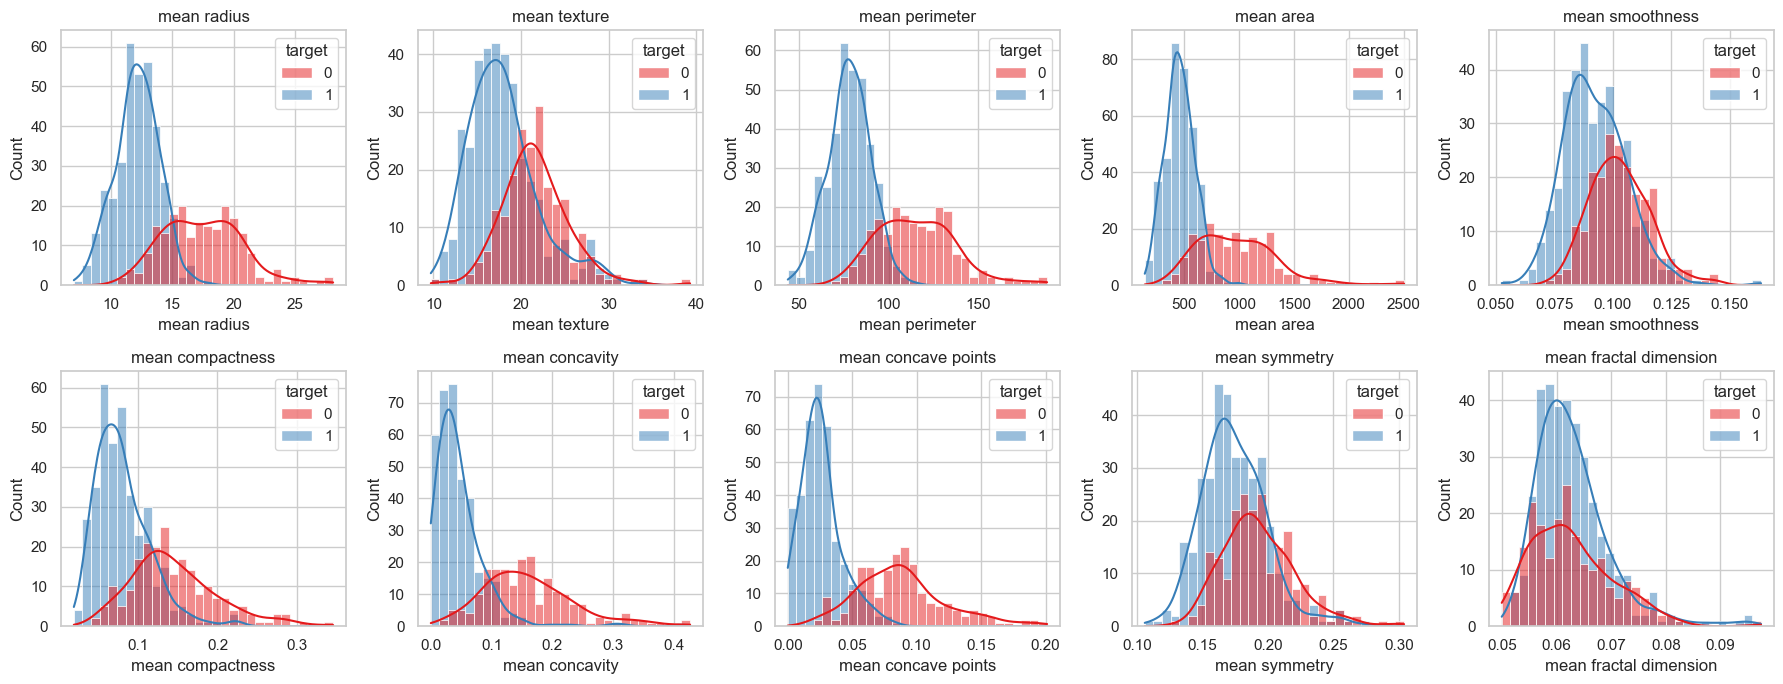

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flat, mean_cols):
    sns.histplot(data=df, x=col, hue=target, kde=True, bins=30, ax=ax, palette="Set1")
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Observation**: Features like `mean radius`, `mean perimeter`, `mean area`, `mean concavity`, and `mean concave points` show **clear class separation** — malignant tumors tend to have larger and more irregular nuclei. Features like `mean smoothness`, `mean symmetry`, and `mean fractal dimension` overlap heavily — they're weaker predictors on their own.

## 7. Boxplots: `worst` features vs. target

The "worst" (largest) measurements often carry more signal than means — outlier nuclei matter clinically.

/var/folders/r0/nz47j5qs2wlcz2b0shdjx1tr0000gn/T/ipykernel_89611/661987955.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["malignant", "benign"])
/var/folders/r0/nz47j5qs2wlcz2b0shdjx1tr0000gn/T/ipykernel_89611/661987955.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["malignant", "benign"])
/var/folders/r0/nz47j5qs2wlcz2b0shdjx1tr0000gn/T/ipykernel_89611/661987955.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["malignant", "benign"])
/var/folders/r0/nz47j5qs2wlcz2b0shdjx1tr0000gn/T/ipykernel_89611/661987955.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["mal

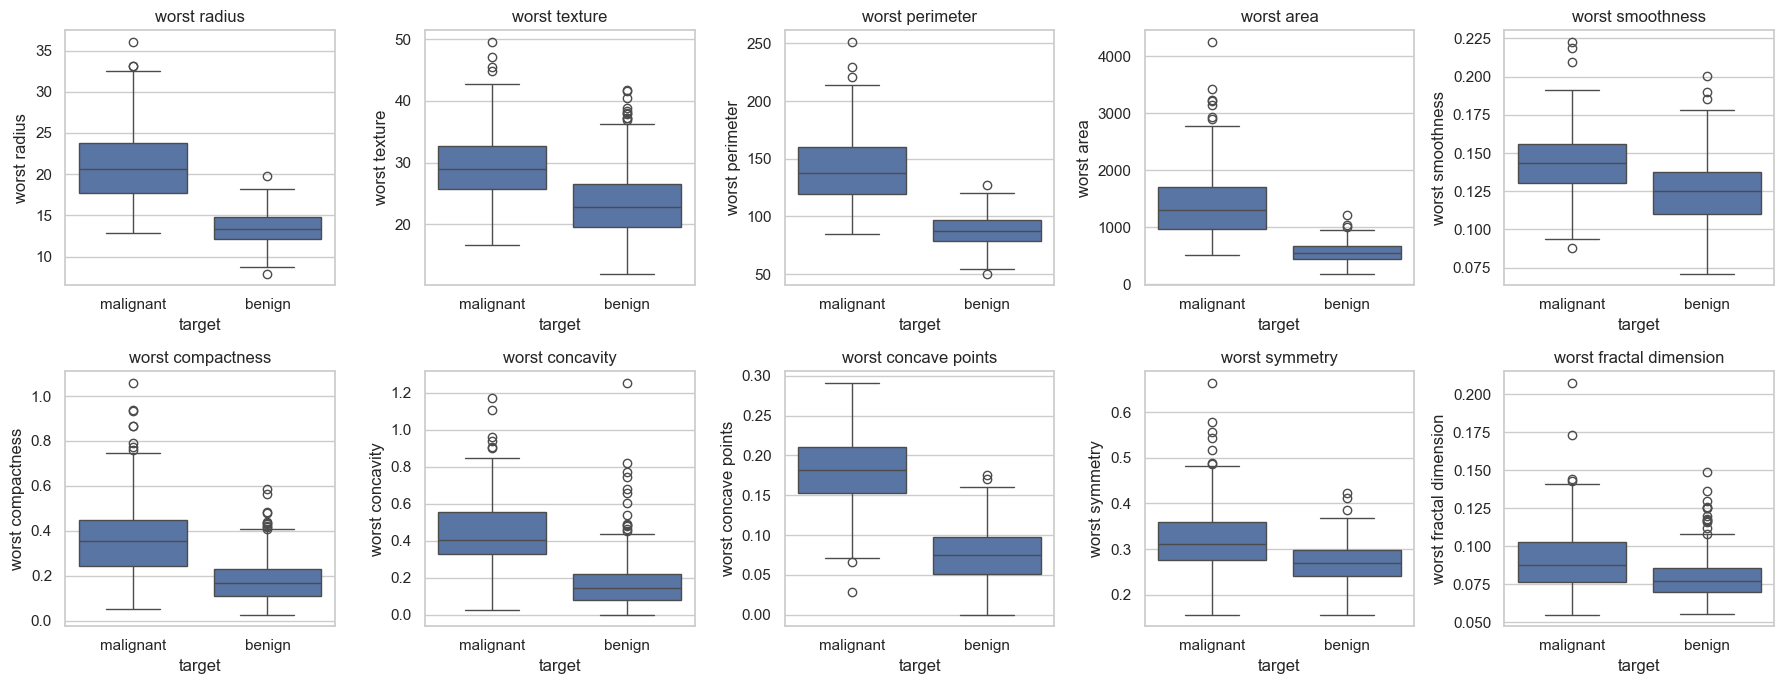

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flat, worst_cols):
    sns.boxplot(data=df, x=target, y=col, ax=ax)
    ax.set_title(col)
    ax.set_xticklabels(["malignant", "benign"])
plt.tight_layout()
plt.show()

## 8. Univariate feature ranking

Which individual features separate the classes best? Two quick views:

1. **|Correlation with target|** — a simple linear measure
2. **ANOVA F-statistic** (`f_classif`) — measures how well a feature's mean differs between classes

Both should largely agree.

In [ ]:
from sklearn.feature_selection import f_classif

corr_with_target = df[num_cols].corrwith(df[target]).abs()
f_stats, _ = f_classif(df[num_cols], df[target])

ranking = pd.DataFrame({
    "abs_corr": corr_with_target,
    "f_stat":   f_stats,
}, index=num_cols).sort_values("f_stat", ascending=False)

ranking.round(2).head(15)

In [ ]:
# Visualize the top 15
top15 = ranking.head(15).sort_values("abs_corr")
plt.figure(figsize=(8, 6))
plt.barh(top15.index, top15["abs_corr"])
plt.xlabel("|correlation with target|")
plt.title("Top 15 features by absolute correlation with target")
plt.tight_layout()
plt.show()

## 9. Correlation analysis & multicollinearity

Showing all 30×30 correlations is overwhelming. Let's first focus on the `mean` group plus target.

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[mean_cols + [target]].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
)
plt.title("Correlations — mean features + target")
plt.show()

**Observation — strong multicollinearity**:

- `mean radius`, `mean perimeter`, and `mean area` are correlated at **~0.99** with each other — geometrically they all measure size.
- `mean concavity`, `mean concave points`, and `mean compactness` cluster together (~0.8–0.9) — they all describe contour irregularity.

**Why this matters for modeling**:
- **Linear models** (Logistic Regression) get unstable coefficients when predictors are highly correlated. Regularization (L1/L2) or dimensionality reduction (PCA) helps.
- **Tree-based models** (RandomForest, GradientBoosting) are robust to multicollinearity — they just pick one of the redundant features at each split.
- **Feature interpretability suffers**: "area was the most important feature" could just as well be said about radius or perimeter — they're carrying the same information.

In [ ]:
# Highly correlated feature pairs across the full dataset (|corr| > 0.9)
corr = df[num_cols].corr().abs()
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
)
print("Feature pairs with |correlation| > 0.9:")
print(pairs[pairs > 0.9].round(3))

## 10. Pairplot — selected features

Picking a handful of the top-ranked features to visualize joint distributions and class separation.

In [ ]:
selected = ["mean radius", "mean texture", "mean concave points", "worst radius", "worst concave points", target]
sns.pairplot(df[selected], hue=target, palette="Set1", diag_kind="kde", plot_kws={"alpha": 0.6})
plt.show()

**Observation**: The classes are almost linearly separable in several 2D projections — this is a hint that even a simple linear model (logistic regression) should do very well here.

---
## 11. Preprocessing & train/test split

Since all features are numerical, the `ColumnTransformer` has only one branch — `StandardScaler`. No imputation, no one-hot encoding needed (contrast with the Adult notebook).

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target])
y = df[target]

prep = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

## 12. Model comparison (cross-validation on the training set)

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

models = {
    "KNN":              make_pipeline(prep, KNeighborsClassifier(n_neighbors=5)),
    "SVM":              make_pipeline(prep, SVC(probability=True)),
    "LogReg":           make_pipeline(prep, LogisticRegression(max_iter=5000)),
    "DecisionTree":     make_pipeline(prep, DecisionTreeClassifier(random_state=42)),
    "RandomForest":     make_pipeline(prep, RandomForestClassifier(random_state=42, n_jobs=-1)),
    "GradientBoosting": make_pipeline(prep, GradientBoostingClassifier(random_state=42)),
    "Baseline (dummy)": make_pipeline(prep, DummyClassifier(strategy="most_frequent")),
}

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

rows = []
for name, model in models.items():
    cv = cross_validate(model, X_train, y_train, cv=5, scoring=scoring, n_jobs=-1)
    rows.append({"model": name, **{m: cv[f"test_{m}"].mean() for m in scoring}})

results = pd.DataFrame(rows).set_index("model").round(3).sort_values("roc_auc", ascending=False)
results

**Observation**: Almost every non-trivial model scores **ROC-AUC > 0.97** — the classes are very separable, and the bottleneck isn't model choice but careful evaluation. Logistic Regression and SVM tend to lead because the decision boundary is close to linear after scaling.

## 13. Confusion matrices (cross-validated predictions)

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (name, model) in zip(axes.flat, models.items()):
    y_pred = cross_val_predict(model, X_train, y_train, cv=5, n_jobs=-1)
    ConfusionMatrixDisplay.from_predictions(
        y_train, y_pred,
        display_labels=["malignant", "benign"],
        ax=ax, colorbar=False,
    )
    ax.set_title(name)
for ax in axes.flat[len(models):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Clinical lens**: Look at the bottom-left cell (false negatives — predicted benign, actually malignant). In a medical setting, that's the most expensive type of error. Models with similar overall accuracy can differ a lot on this specific number.

## 14. Hyperparameter tuning (GridSearch for SVM)

In [ ]:
from sklearn.model_selection import GridSearchCV

svm_pipe = make_pipeline(prep, SVC(probability=True))

param_grid = {
    "svc__C":      [0.1, 1, 10],
    "svc__kernel": ["linear", "rbf"],
    "svc__gamma":  ["scale", "auto"],
}

grid_search = GridSearchCV(
    svm_pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1, verbose=1,
)
grid_search.fit(X_train, y_train)

print("best params:    ", grid_search.best_params_)
print("best cv roc_auc:", round(grid_search.best_score_, 3))

## 15. Final evaluation on the held-out test set

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

best = grid_search.best_estimator_
y_pred  = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["malignant", "benign"], ax=axes[0]
)
axes[0].set_title("Confusion matrix — test set")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_title("ROC curve — test set")
plt.tight_layout()
plt.show()

## 16. Feature importance — the permutation method

To rank features by actual predictive power, we use **permutation importance**:

1. Compute the model's baseline score on the test set
2. Take one feature, **shuffle its values randomly** (breaking its link to the target)
3. Re-compute the score — the drop tells us how much the model relied on that feature
4. Repeat for every feature, several times, and average the score drops

**Advantages over `feature_importances_` (which only tree models have)**:
- Works with **any model** (SVM, logistic regression, neural net, ensemble)
- Measured on **held-out data**, so it reflects generalization, not training-set quirks
- Comes with an uncertainty estimate (the shuffle is repeated `n_repeats` times)

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="roc_auc",
)

importances = pd.Series(
    result.importances_mean,
    index=X_test.columns,
).sort_values()

# Top 15 features (otherwise the chart gets crowded)
top = importances.tail(15)

plt.figure(figsize=(8, 6))
top.plot.barh()
plt.xlabel("Mean ROC-AUC drop when the feature is shuffled")
plt.title("Top 15 features by permutation importance (test set)")
plt.tight_layout()
plt.show()

**Reading the chart**: a bar of `0.10` means that randomly shuffling that feature's column dropped the test ROC-AUC by 0.10 on average. Longer bar → the model relies more on that feature.

**Watch out — the multicollinearity trap**: because `radius`, `perimeter`, and `area` all carry essentially the same information, shuffling just one of them barely hurts the model — it still has the other two. As a result, permutation importance **underestimates** the joint importance of correlated features.

**Sanity check** — comparison with the built-in feature importance of a Random Forest. Tree-based feature importance is computed differently (mean impurity decrease across splits) and behaves differently under multicollinearity: at each split, the tree just picks *one* of the correlated features, so the importance gets distributed somewhat arbitrarily between them.

In [ ]:
rf = make_pipeline(prep, RandomForestClassifier(random_state=42, n_jobs=-1))
rf.fit(X_train, y_train)

rf_importances = pd.Series(
    rf.named_steps["randomforestclassifier"].feature_importances_,
    index=num_cols,
).sort_values()

plt.figure(figsize=(8, 6))
rf_importances.tail(15).plot.barh(color="darkgreen")
plt.xlabel("Mean decrease in impurity (Gini)")
plt.title("Top 15 features by Random Forest built-in importance")
plt.tight_layout()
plt.show()

## 17. Outlook — what to try next

- **PCA**: Given the strong multicollinearity (radius ≈ perimeter ≈ area), the first 5–10 principal components likely capture > 95% of the variance. Try `PCA(n_components=0.95)` as a step before the classifier.
- **Feature selection**: Use `SelectKBest(f_classif, k=10)` or `SelectFromModel(LogisticRegression(penalty="l1"))` and see whether a smaller feature set matches the full-feature performance.
- **Recall-first threshold**: For a medical application, sweep the decision threshold to maximize recall at a tolerable precision (precision-recall curve, not just the default 0.5 threshold).
- **Permutation importance**: After fitting the best model, compute `permutation_importance` to get a model-agnostic ranking — and notice how the importance gets "split" across correlated features.
- **Calibration**: Are the predicted probabilities well-calibrated? Plot a calibration curve (`CalibrationDisplay`). For medical risk scores, calibration matters as much as discrimination.